Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**  
Course: **Computer Engineering - Artificial Intelligence / Machine Learning**

**Exam Sample Problem: Regression**

**Scenario:**<p> 
A neighborhood coffee shop manager wants to predict daily peso sales so the shop can right-size its
bean orders, pastry stock, and barista shifts each day. Each business day she logs the day type (regular
weekday, weekend, or holiday), the dominant weather, average temperature, rainfall, foot traffic past the
storefront, the active promotional discount, and how many hours the store stayed open — together with
the day's recorded sales in PHP. She wants a model that, given tomorrow's forecasted conditions and
her planned promo and hours, predicts daily sales so she can avoid over- or under-stocking.
</p>


**Given Dataset:**

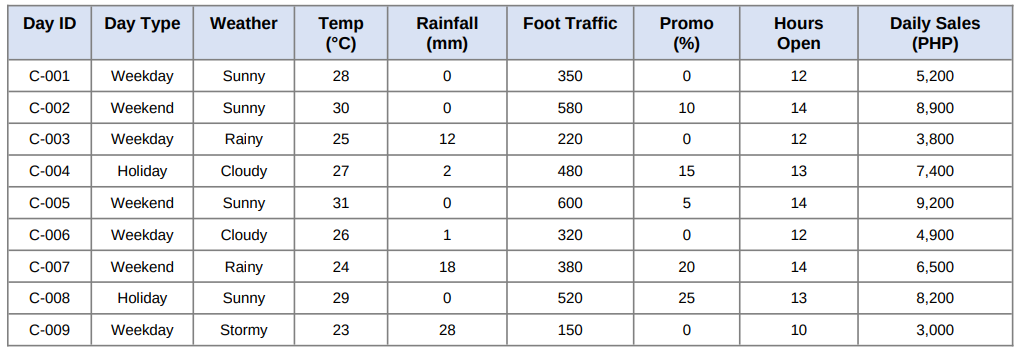

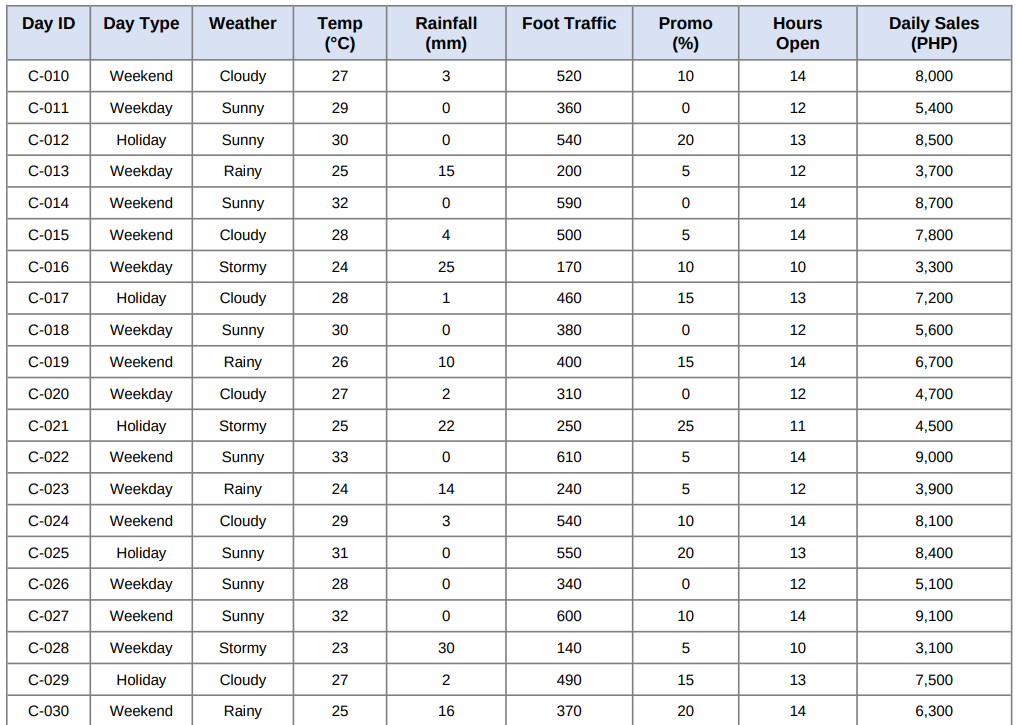

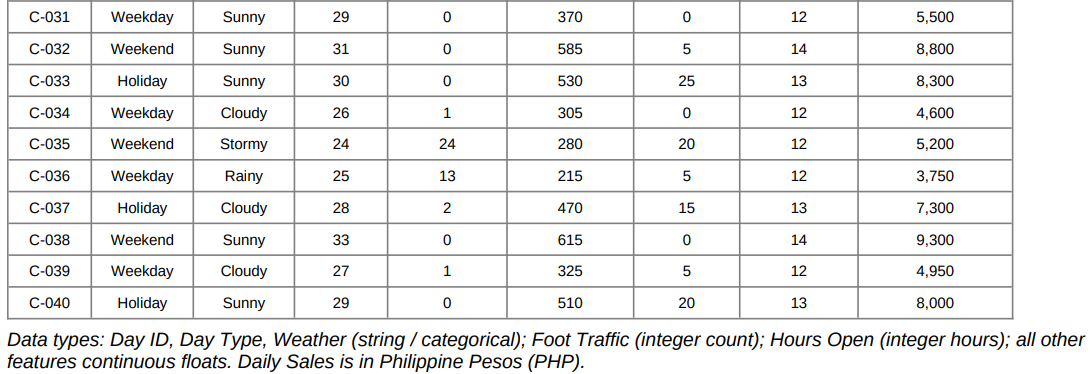


---

#### **I. Import Libraries**

In [162]:
import tensorflow as tf 
import pandas as pd 
import numpy as np 
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder


print(f'tensorflow: {tf.__version__}\n', 
      f'pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}')

tensorflow: 2.21.0
 pandas: 3.0.2
 numpy: 2.4.2
 sklearn: 1.8.0


#### **II. Prep Dataset**

In [163]:
data = pd.read_csv("work/ai-1/Assessments/Sample1/CoffeeShopSampleData.csv")

data

,Day ID,Day Type,Weather,Temp (C),Rainfall (mm),Foot Traffic,Promo (%),Hours Open,Daily Sales (PHP)
0,C-001,Weekday,Sunny,28,0,350,0,12,5200
1,C-002,Weekend,Sunny,30,0,580,10,14,8900
2,C-003,Weekday,Rainy,25,12,220,0,12,3800
3,C-004,Holiday,Cloudy,27,2,480,15,13,7400
4,C-005,Weekend,Sunny,31,0,600,5,14,9200
5,C-006,Weekday,Cloudy,26,1,320,0,12,4900
6,C-007,Weekend,Rainy,24,18,380,20,14,6500
7,C-008,Holiday,Sunny,29,0,520,25,13,8200
8,C-009,Weekday,Stormy,23,28,150,0,10,3000
9,C-010,Weekend,Cloudy,27,3,520,10,14,8000


In [164]:
X = data.drop(["Daily Sales (PHP)"], axis=1)
y = data["Daily Sales (PHP)"]

X, y

(   Day ID Day Type Weather  Temp (C)  Rainfall (mm)  Foot Traffic  Promo (%)  \
 0   C-001  Weekday   Sunny        28              0           350          0   
 1   C-002  Weekend   Sunny        30              0           580         10   
 2   C-003  Weekday   Rainy        25             12           220          0   
 3   C-004  Holiday  Cloudy        27              2           480         15   
 4   C-005  Weekend   Sunny        31              0           600          5   
 5   C-006  Weekday  Cloudy        26              1           320          0   
 6   C-007  Weekend   Rainy        24             18           380         20   
 7   C-008  Holiday   Sunny        29              0           520         25   
 8   C-009  Weekday  Stormy        23             28           150          0   
 9   C-010  Weekend  Cloudy        27              3           520         10   
 10  C-011  Weekday   Sunny        29              0           360          0   
 11  C-012  Holiday   Sunny 

In [165]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    shuffle=False,
                                                    train_size=0.75
                                                    )

X_train

,Day ID,Day Type,Weather,Temp (C),Rainfall (mm),Foot Traffic,Promo (%),Hours Open
0,C-001,Weekday,Sunny,28,0,350,0,12
1,C-002,Weekend,Sunny,30,0,580,10,14
2,C-003,Weekday,Rainy,25,12,220,0,12
3,C-004,Holiday,Cloudy,27,2,480,15,13
4,C-005,Weekend,Sunny,31,0,600,5,14
5,C-006,Weekday,Cloudy,26,1,320,0,12
6,C-007,Weekend,Rainy,24,18,380,20,14
7,C-008,Holiday,Sunny,29,0,520,25,13
8,C-009,Weekday,Stormy,23,28,150,0,10
9,C-010,Weekend,Cloudy,27,3,520,10,14


In [166]:
X_test

,Day ID,Day Type,Weather,Temp (C),Rainfall (mm),Foot Traffic,Promo (%),Hours Open
30,C-031,Weekday,Sunny,29,0,370,0,12
31,C-032,Weekend,Sunny,31,0,585,5,14
32,C-033,Holiday,Sunny,30,0,530,25,13
33,C-034,Weekday,Cloudy,26,1,305,0,12
34,C-035,Weekend,Stormy,24,24,280,20,12
35,C-036,Weekday,Rainy,25,13,215,5,12
36,C-037,Holiday,Cloudy,28,2,470,15,13
37,C-038,Weekend,Sunny,33,0,615,0,14
38,C-039,Weekday,Cloudy,27,1,325,5,12
39,C-040,Holiday,Sunny,29,0,510,20,13


In [167]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_str = encoder.fit_transform(X_train[["Day Type", "Weather"]])
X_test_str = encoder.transform(X_test[["Day Type", "Weather"]])

X_train_str

array([[0., 1., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1., 0., 0.],
       [1., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1., 0., 0.],
       [0., 1., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1., 0., 0.],
       [0., 0., 1., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 1.],
 

In [168]:
#y_train_str = encoder.fit_transform(y_train)

In [169]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[["Temp (C)", "Rainfall (mm)", "Foot Traffic", "Promo (%)", "Hours Open"]])
X_test_scaled = scaler.transform(X_test[["Temp (C)", "Rainfall (mm)", "Foot Traffic", "Promo (%)", "Hours Open"]])

X_train_scaled

array([[ 0.16873594, -0.73855515, -0.37951012, -1.11063159, -0.55167728],
       [ 0.89188999, -0.73855515,  1.19797171,  0.12340351,  1.02454353],
       [-0.91599512,  0.53971338, -1.27113028, -1.11063159, -0.55167728],
       [-0.19284108, -0.5255104 ,  0.51211004,  0.74042106,  0.23643312],
       [ 1.25346701, -0.73855515,  1.33514404, -0.49361404,  1.02454353],
       [-0.5544181 , -0.63203278, -0.58526862, -1.11063159, -0.55167728],
       [-1.27757215,  1.17884765, -0.17375162,  1.35743862,  1.02454353],
       [ 0.53031297, -0.73855515,  0.78645471,  1.97445617,  0.23643312],
       [-1.63914917,  2.24407143, -1.75123345, -1.11063159, -2.1278981 ],
       [-0.19284108, -0.41898802,  0.78645471,  0.12340351,  1.02454353],
       [ 0.53031297, -0.73855515, -0.31092395, -1.11063159, -0.55167728],
       [ 0.89188999, -0.73855515,  0.92362704,  1.35743862,  0.23643312],
       [-0.91599512,  0.85928052, -1.40830262, -0.49361404, -0.55167728],
       [ 1.61504403, -0.73855515,  1.2

In [170]:
X_train_final = np.concat([X_train_str, X_train_scaled], axis=1)

X_test_final = np.concat([X_test_str, X_test_scaled], axis=1)

pd.DataFrame(X_test_final)

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.530313,-0.738555,-0.242338,-1.110632,-0.551677
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.253467,-0.738555,1.232265,-0.493614,1.024544
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.891890,-0.738555,0.855041,1.974456,0.236433
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.554418,-0.632033,-0.688148,-1.110632,-0.551677
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.277572,1.817982,-0.859613,1.357439,-0.551677
5,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.915995,0.646236,-1.305423,-0.493614,-0.551677
6,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.168736,-0.525510,0.443524,0.740421,0.236433
7,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.976621,-0.738555,1.438023,-1.110632,1.024544
8,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.192841,-0.632033,-0.550976,-0.493614,-0.551677
9,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.530313,-0.738555,0.717869,1.357439,0.236433


#### **III. Build the Model**

In [171]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[X_train_final.shape[1]]),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear'),
])

In [172]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [173]:
model.compile(loss='mse',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
              )

In [174]:
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

In [175]:
history = model.fit(X_train_final, y_train_scaled,
                    epochs=200,
                    validation_split=0.2,
                    batch_size=8)

Epoch 1/200


I0000 00:00:1779211484.881302  142592 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_58169__.6


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - loss: 0.7922 - val_loss: 0.8295
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7438 - val_loss: 0.7656
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6978 - val_loss: 0.7070
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.6527 - val_loss: 0.6530
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6124 - val_loss: 0.6064
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.5737 - val_loss: 0.5610
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.5382 - val_loss: 0.5185
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.5056 - val_loss: 0.4776
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.4701 - val_loss: 0.4407
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.4382 - val_loss: 0.4068
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.4093 - val_loss: 0.3769
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.3823 - val_loss: 0.3480


In [176]:
evalu = model.evaluate(X_test_final, y_test)
evalu

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - loss: 46707880.0000


46707880.0

#### **IV. Display Results**

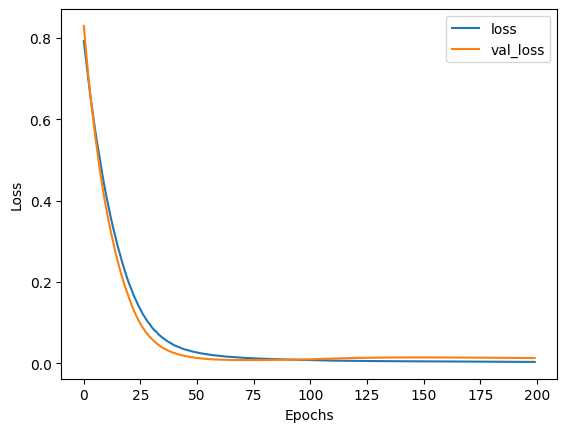

In [177]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

In [178]:
y_pred_scaled = model.predict(X_test_final)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


In [179]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} PHP")
print(f"RMSE: {rmse:.2f} PHP")
print(f"R²:   {r2:.4f}")

MAE:  197.12 PHP
RMSE: 266.36 PHP
R²:   0.9800


In [180]:
results_df = pd.DataFrame({
    'Day ID': X_test["Day ID"], # Replace with the ID column extracted during your 30:10 hold-out split
    'Actual Sales': np.array(y_test).flatten(),
    'Predicted Sales': np.array(y_pred).flatten()
})

results_df['Absolute Error'] = abs(results_df['Actual Sales'] - results_df['Predicted Sales'])

print(results_df)

   Day ID  Actual Sales  Predicted Sales  Absolute Error
30  C-031          5500      5486.081543       13.918457
31  C-032          8800      8926.069336      126.069336
32  C-033          8300      8400.264648      100.264648
33  C-034          4600      4805.354980      205.354980
34  C-035          5200      4624.118164      575.881836
35  C-036          3750      3894.974609      144.974609
36  C-037          7300      7352.991699       52.991699
37  C-038          9300      8863.557617      436.442383
38  C-039          4950      4956.750488        6.750488
39  C-040          8000      8308.520508      308.520508
